# LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from collections import defaultdict


In [2]:
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE

In [3]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [4]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [5]:
from imblearn.pipeline import Pipeline          # ← key fix
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [6]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold


class CascadeDecisionTreeClassifier(BaseEstimator, ClassifierMixin):
    """
    Cascade of binary Decision Trees for multiclass classification.

    Step 1 → class 0 vs [1, 2, 3]
    Step 2 → class 1 vs [2, 3]      (only samples not predicted as 0)
    Step 3 → class 2 vs [3]         (only samples not predicted as 0 or 1)
    Step 4 → class 3                (remaining samples)
    """

    def __init__(self, n_iter=200, n_splits=10, random_state=0):
        self.n_iter       = n_iter
        self.n_splits     = n_splits
        self.random_state = random_state

        # one trained model per cascade step
        self.models_      = {}
        self.best_params_ = {}
        self.best_scores_ = {}
        self.classes_     = None
        self.info_        = None

    # ── Internal random search for one binary step ────────────────────────────
    def _train_binary_step(self, X, y_binary, step_name):
        """
        Trains one binary Decision Tree with RandomizedSearchCV.
        y_binary must be 0 (negative class) or 1 (positive class).
        """
        param_list = {
            'max_depth':         [None] + list(np.arange(2, 20)),
            'min_samples_split': [0.002, 0.01, 0.03, 0.05, 0.1, 0.2],
            'min_samples_leaf':  [5, 10, 20, 30, 50, 100, 150],
            'criterion':         ['gini', 'entropy'],
            'class_weight':      ['balanced',
                                  {0: 1, 1: 2},
                                  {0: 1, 1: 5},
                                  {0: 1, 1: 10},
                                  None],
        }

        random_search = RandomizedSearchCV(
            DecisionTreeClassifier(random_state=self.random_state),
            param_distributions=param_list,
            cv=KFold(n_splits=self.n_splits, shuffle=True,
                     random_state=self.random_state),
            scoring='f1_weighted',
            n_jobs=-1,
            refit=True,
            n_iter=self.n_iter,
            random_state=self.random_state,
        )
        random_search.fit(X, y_binary)

        best_model = random_search.best_estimator_
        best_model.fit(X, y_binary)

        print(f"  [{step_name}] best params  : {random_search.best_params_}")
        print(f"  [{step_name}] best F1 score: {random_search.best_score_:.4f}")
        print(f"  [{step_name}] samples used : {len(y_binary)}")
        print()

        return best_model, random_search.best_params_, random_search.best_score_

    # ── Fit — trains all cascade steps ───────────────────────────────────────
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_classes     = len(self.classes_)

        print("=" * 60)
        print("CASCADE DECISION TREE — TRAINING")
        print("=" * 60)
        print(f"  Classes   : {self.classes_}")
        print(f"  n_classes : {n_classes}")
        print(f"  n_samples : {len(y)}")
        print("=" * 60)
        print()

        X_remaining = X.copy()
        y_remaining = y.copy()

        # train one binary classifier per class except the last
        for i, cls in enumerate(self.classes_[:-1]):

            step_name = (f"class {cls} vs "
                         f"{list(self.classes_[i+1:])}")

            print(f"── Step {i+1}: {step_name} ──")

            # binary label: 1 = current class, 0 = all remaining classes
            y_binary = (y_remaining == cls).astype(int)

            model, best_params, best_score = self._train_binary_step(
                X_remaining, y_binary, step_name
            )

            self.models_[cls]      = model
            self.best_params_[cls] = best_params
            self.best_scores_[cls] = best_score

            # keep only samples NOT predicted as current class
            mask        = model.predict(X_remaining) == 0
            X_remaining = X_remaining[mask]
            y_remaining = y_remaining[mask]

            print(f"  Remaining samples for next step: {len(y_remaining)}")
            print()

        # last class — no model needed, all remaining = last class
        last_cls = self.classes_[-1]
        self.models_[last_cls]      = None
        self.best_params_[last_cls] = 'all remaining → assigned directly'
        self.best_scores_[last_cls] = None

        # store info
        self.info_ = {
            'classes':      self.classes_,
            'n_classes':    n_classes,
            'models':       self.models_,
            'best_params':  self.best_params_,
            'best_scores':  self.best_scores_,
        }

        print("=" * 60)
        print("TRAINING COMPLETE — SUMMARY")
        print("=" * 60)
        for cls in self.classes_[:-1]:
            print(f"  Class {cls} → F1: {self.best_scores_[cls]:.4f} "
                  f"| {self.best_params_[cls]}")
        print(f"  Class {last_cls} → assigned to all remaining samples")
        print("=" * 60)

        return self

    # ── Predict — runs each sample through the cascade ────────────────────────
    def predict(self, X):
        n_samples      = len(X)
        y_pred         = np.full(n_samples, self.classes_[-1])  # default = last class
        remaining_idx  = np.arange(n_samples)                   # indices still unassigned

        for cls in self.classes_[:-1]:
            if len(remaining_idx) == 0:
                break

            X_remaining = X[remaining_idx]
            binary_pred = self.models_[cls].predict(X_remaining)

            # samples predicted as current class → assign and remove from pipeline
            positive_mask              = binary_pred == 1
            y_pred[remaining_idx[positive_mask]] = cls

            # keep only the negatives for the next step
            remaining_idx = remaining_idx[~positive_mask]

        return y_pred

    # ── Predict proba — probability per class ────────────────────────────────
    def predict_proba(self, X):
        n_samples  = len(X)
        n_classes  = len(self.classes_)
        proba      = np.zeros((n_samples, n_classes))

        remaining_idx     = np.arange(n_samples)
        survival_proba    = np.ones(n_samples)   # probability of reaching each step

        for i, cls in enumerate(self.classes_[:-1]):
            if len(remaining_idx) == 0:
                break

            X_remaining  = X[remaining_idx]
            step_proba   = self.models_[cls].predict_proba(X_remaining)

            # probability of being this class = P(reach step) × P(positive | step)
            p_positive = step_proba[:, 1]
            p_negative = step_proba[:, 0]

            proba[remaining_idx, i] = survival_proba[remaining_idx] * p_positive

            # update survival probability for the next step
            survival_proba[remaining_idx] *= p_negative

            # keep only negatives
            negative_mask = self.models_[cls].predict(X_remaining) == 0
            remaining_idx = remaining_idx[negative_mask]

        # last class gets whatever probability is left
        proba[remaining_idx, -1] = survival_proba[remaining_idx]

        return proba




# READ DATAFRAME

In [82]:
file_path = "../1.DATASET/CMI_FINAL_OD_SS.csv"
df=pd.read_csv(file_path)

In [83]:
df

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
0,0,-1.467073,-0.822843,-0.561893,-1.343231,-1.008221,-0.250870,-0.956432,-0.428812,-0.942872,-0.939966,-0.992591,-0.818300,-0.947148,-0.726336,-1.265162,-0.874740,-0.859871,2.0
1,1,-0.338700,-0.822843,-1.221382,-1.083906,-1.128018,0.630346,-0.657546,-0.367405,1.285851,-0.939966,-1.033298,-0.804797,-0.932563,-1.053662,-1.265162,-1.226847,-1.273565,0.0
2,2,-0.056607,1.215298,-0.614950,0.018225,-0.389269,-0.232187,1.018179,-1.466511,0.790579,0.280796,-0.662859,-0.199213,-0.347769,-0.314411,0.512640,-0.355318,-0.148634,0.0
3,3,-0.338700,-0.822843,-0.233502,-0.046607,-0.239523,-0.577200,0.665395,-0.367405,-0.695236,0.280796,-0.456268,0.057750,-0.249394,-0.126332,0.512640,-0.283279,0.116846,1.0
4,4,2.200139,1.215298,-0.315811,-0.224763,-0.375806,0.577087,-0.304761,1.210082,-0.198377,0.280796,3.297345,1.538145,-0.330005,-0.314411,0.512640,0.009328,-0.148634,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8377,8455,-0.902887,1.215298,-0.735189,-1.334155,-1.060626,-0.281071,-0.789840,-0.392148,-0.695236,-2.160727,-1.012064,-0.820639,-0.817405,-1.103413,-1.265162,-1.004029,-0.941197,0.0
8378,8456,-0.056607,1.215298,-0.463799,-0.029751,-0.341052,-0.490946,-0.613448,-1.251639,-1.685780,0.280796,0.067523,-0.439950,-0.015430,-0.823890,-1.265162,-0.581341,-0.582047,1.0
8379,8457,-0.056607,1.215298,5.021847,-0.881633,1.293649,-0.249437,0.533101,-0.627980,0.542943,1.501557,-0.388344,-0.705917,1.239140,0.886735,0.512640,0.152734,-0.682526,0.0
8380,8458,1.353859,1.215298,0.742981,0.963464,0.974332,0.395292,-0.481153,1.201246,1.038215,-0.939966,0.058376,-0.447250,1.092211,0.366529,0.512640,1.420549,0.963516,2.0


In [84]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8382, 17)
y shape : (8382,)
Classes : [0. 1. 2. 3.]
Class counts : {0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85}


# CASCASDE

# Data Preparation

In [85]:
X.shape

(8382, 17)

In [86]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3.]), array([5794, 1567,  936,   85], dtype=int64))

In [87]:
Counter(y)

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

In [88]:
ctr = Counter(y)
ctr

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

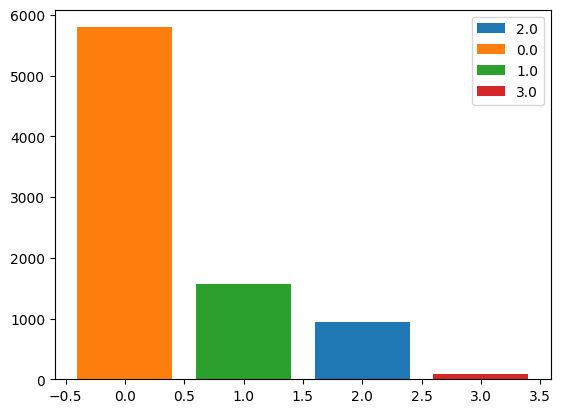

In [89]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange','tab:green','tab:red'])
plt.legend()
plt.show()

## Data Partitioning

In [90]:
from sklearn.model_selection import train_test_split, cross_val_score 

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [92]:
X_train.shape

(5867, 17)

In [93]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0., 1., 2., 3.]), array([4056, 1097,  655,   59], dtype=int64)),
 (array([0., 1., 2., 3.]), array([1738,  470,  281,   26], dtype=int64)))

In [94]:
np.max(np.unique(y_train, return_counts=True)[1])/len(X_train)

0.6913243565706494

In [95]:

print(f"Train samples : {len(y_train)}")
print(f"Test samples  : {len(y_test)}")

Train samples : 5867
Test samples  : 2515


# PIPELINE

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report

In [130]:
param_list = {
    'max_depth':         list(np.arange(2, 50)),
    'min_samples_split': [0.01, 0.03, 0.05, 0.1, 0.2],
    'min_samples_leaf':  [5, 10, 20, 30, 50, 100, 150],
    'criterion':         ['gini', 'entropy'],
    'class_weight':      ['balanced']
}

In [131]:
def train_one_step(X_train, y_binary, X_test, y_test_binary, step_name,
                   n_iter=50, n_splits=5, random_state=0):
    
    print(f"\n{'='*60}")
    print(f"  STEP: {step_name}")
    print(f"  Training samples : {len(y_binary)}")
    print(f"  Positive class   : {y_binary.sum()} samples")
    print(f"  Negative class   : {(y_binary==0).sum()} samples")
    print(f"{'='*60}")

    random_search = RandomizedSearchCV(
        DecisionTreeClassifier(random_state=random_state),
        param_distributions=param_list,
        cv=KFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring='f1_weighted',
        n_jobs=1,
        refit=True,
        n_iter=n_iter,
        random_state=random_state,
    )
    random_search.fit(X_train, y_binary)

    best_model = random_search.best_estimator_
    best_model.fit(X_train, y_binary)    

    print(f"\n  Best params : {random_search.best_params_}")
    print(f"  Best CV F1  : {random_search.best_score_:.4f}")

    y_pred_binary = best_model.predict(X_test)
    test_f1 = f1_score(y_test_binary, y_pred_binary, average='weighted')
    print(f"  Test F1     : {test_f1:.4f}")

    cm = confusion_matrix(y_test_binary, y_pred_binary)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=[f'not {step_name}', step_name])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {step_name}')
    plt.tight_layout()
    plt.show()

    print(classification_report(y_test_binary, y_pred_binary))
    print(f"\n  Confusion Matrix breakdown:")
    print(f"    TN (correct negatives) : {cm[0,0]}")
    print(f"    FP (false positives)   : {cm[0,1]}")
    print(f"    FN (false negatives)   : {cm[1,0]}")
    print(f"    TP (correct positives) : {cm[1,1]}")
    
    return best_model




In [132]:
# Working copies that shrink at each cascade step
X_tr = X_train.copy()
y_tr = y_train.copy()
X_te = X_test.copy()
y_te = y_test.copy()

models  = {}
classes = np.unique(y_train)

print(f"Classes found  : {classes}")
print(f"Train samples  : {len(y_tr)}")
print(f"Test samples   : {len(y_te)}")

Classes found  : [0. 1. 2. 3.]
Train samples  : 5867
Test samples   : 2515


In [133]:
import pandas as pd

unique, counts = np.unique(y_tr, return_counts=True)
proportions = counts / counts.sum()

class_dist = pd.DataFrame({
    'Class':      [f'sii={u}' for u in unique],
    'Count':      counts,
    'Proportion': proportions.round(4),
    'Percentage': (proportions * 100).round(2)
})

print(class_dist.to_string(index=False))

  Class  Count  Proportion  Percentage
sii=0.0   4056      0.6913       69.13
sii=1.0   1097      0.1870       18.70
sii=2.0    655      0.1116       11.16
sii=3.0     59      0.0101        1.01


In [134]:
import pandas as pd

unique, counts = np.unique(y_te, return_counts=True)
proportions = counts / counts.sum()

class_dist = pd.DataFrame({
    'Class':      [f'sii={u}' for u in unique],
    'Count':      counts,
    'Proportion': proportions.round(4),
    'Percentage': (proportions * 100).round(2)
})

print(class_dist.to_string(index=False))

  Class  Count  Proportion  Percentage
sii=0.0   1738      0.6911       69.11
sii=1.0    470      0.1869       18.69
sii=2.0    281      0.1117       11.17
sii=3.0     26      0.0103        1.03


In [135]:
# ── STEP 1: sii=0 vs [1, 2, 3] ───────────────────────────────────────────
y_binary_tr = (y_tr == 0).astype(int)
y_binary_te = (y_te == 0).astype(int)


In [136]:
import pandas as pd

unique, counts = np.unique(y_binary_tr, return_counts=True)
proportions = counts / counts.sum()

class_dist = pd.DataFrame({
    'Class':      [f'sii={u}' for u in unique],
    'Count':      counts,
    'Proportion': proportions.round(4),
    'Percentage': (proportions * 100).round(2)
})

print(class_dist.to_string(index=False))
unique, counts = np.unique(y_binary_te, return_counts=True)
proportions = counts / counts.sum()

class_dist = pd.DataFrame({
    'Class':      [f'sii={u}' for u in unique],
    'Count':      counts,
    'Proportion': proportions.round(4),
    'Percentage': (proportions * 100).round(2)
})

print(class_dist.to_string(index=False))

Class  Count  Proportion  Percentage
sii=0   1811      0.3087       30.87
sii=1   4056      0.6913       69.13
Class  Count  Proportion  Percentage
sii=0    777      0.3089       30.89
sii=1   1738      0.6911       69.11



  STEP: sii=0
  Training samples : 5867
  Positive class   : 4056 samples
  Negative class   : 1811 samples

  Best params : {'min_samples_split': 0.1, 'min_samples_leaf': 150, 'max_depth': 2, 'criterion': 'gini', 'class_weight': 'balanced'}
  Best CV F1  : 0.6435
  Test F1     : 0.6521


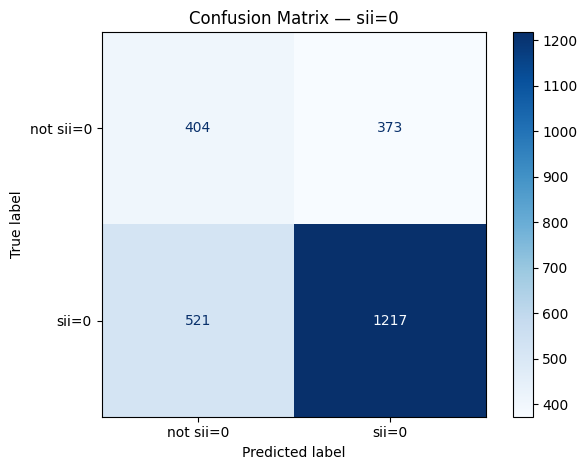

              precision    recall  f1-score   support

           0       0.44      0.52      0.47       777
           1       0.77      0.70      0.73      1738

    accuracy                           0.64      2515
   macro avg       0.60      0.61      0.60      2515
weighted avg       0.66      0.64      0.65      2515


  Confusion Matrix breakdown:
    TN (correct negatives) : 404
    FP (false positives)   : 373
    FN (false negatives)   : 521
    TP (correct positives) : 1217


In [137]:
models[0] = train_one_step(X_tr, y_binary_tr, X_te, y_binary_te,
                            step_name='sii=0')

In [138]:
#Remove samples predicted as sii=0 before next step
mask_tr = y_tr != 0
mask_te = y_te != 0

X_tr, y_tr = X_tr[mask_tr], y_tr[mask_tr]
X_te, y_te = X_te[mask_te], y_te[mask_te]

print(f"\n  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")


  Remaining train : 1811
  Remaining test  : 777


In [139]:
# ── STEP 2: sii=1 vs [2, 3] ──────────────────────────────────────────────
y_binary_tr = (y_tr == 1).astype(int)
y_binary_te = (y_te == 1).astype(int)


In [140]:
import pandas as pd

unique, counts = np.unique(y_binary_tr, return_counts=True)
proportions = counts / counts.sum()

class_dist = pd.DataFrame({
    'Class':      [f'sii={u}' for u in unique],
    'Count':      counts,
    'Proportion': proportions.round(4),
    'Percentage': (proportions * 100).round(2)
})

print(class_dist.to_string(index=False))
unique, counts = np.unique(y_binary_te, return_counts=True)
proportions = counts / counts.sum()

class_dist = pd.DataFrame({
    'Class':      [f'sii={u}' for u in unique],
    'Count':      counts,
    'Proportion': proportions.round(4),
    'Percentage': (proportions * 100).round(2)
})

print(class_dist.to_string(index=False))

Class  Count  Proportion  Percentage
sii=0    714      0.3943       39.43
sii=1   1097      0.6057       60.57
Class  Count  Proportion  Percentage
sii=0    307      0.3951       39.51
sii=1    470      0.6049       60.49



  STEP: sii=1
  Training samples : 1811
  Positive class   : 1097 samples
  Negative class   : 714 samples

  Best params : {'min_samples_split': 0.05, 'min_samples_leaf': 50, 'max_depth': 2, 'criterion': 'gini', 'class_weight': 'balanced'}
  Best CV F1  : 0.5694
  Test F1     : 0.5888


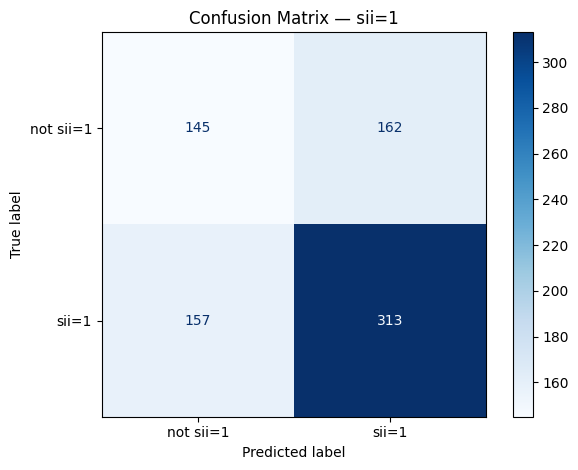

              precision    recall  f1-score   support

           0       0.48      0.47      0.48       307
           1       0.66      0.67      0.66       470

    accuracy                           0.59       777
   macro avg       0.57      0.57      0.57       777
weighted avg       0.59      0.59      0.59       777


  Confusion Matrix breakdown:
    TN (correct negatives) : 145
    FP (false positives)   : 162
    FN (false negatives)   : 157
    TP (correct positives) : 313


In [141]:
models[1] = train_one_step(X_tr, y_binary_tr, X_te, y_binary_te,
                            step_name='sii=1')

In [142]:
#Remove samples predicted as sii=1 before next step
mask_tr = y_tr != 1
mask_te = y_te != 1

X_tr, y_tr = X_tr[mask_tr], y_tr[mask_tr]
X_te, y_te = X_te[mask_te], y_te[mask_te]

print(f"\n  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")


  Remaining train : 714
  Remaining test  : 307


In [143]:
# sii= 2 vs [3] ──────────────────────────────────────────────
y_binary_tr = (y_tr == 2).astype(int)
y_binary_te = (y_te == 2).astype(int)

In [144]:
import pandas as pd

unique, counts = np.unique(y_binary_tr, return_counts=True)
proportions = counts / counts.sum()

class_dist = pd.DataFrame({
    'Class':      [f'sii={u}' for u in unique],
    'Count':      counts,
    'Proportion': proportions.round(4),
    'Percentage': (proportions * 100).round(2)
})

print(class_dist.to_string(index=False))
unique, counts = np.unique(y_binary_te, return_counts=True)
proportions = counts / counts.sum()

class_dist = pd.DataFrame({
    'Class':      [f'sii={u}' for u in unique],
    'Count':      counts,
    'Proportion': proportions.round(4),
    'Percentage': (proportions * 100).round(2)
})

print(class_dist.to_string(index=False))

Class  Count  Proportion  Percentage
sii=0     59      0.0826        8.26
sii=1    655      0.9174       91.74
Class  Count  Proportion  Percentage
sii=0     26      0.0847        8.47
sii=1    281      0.9153       91.53



  STEP: sii=2
  Training samples : 714
  Positive class   : 655 samples
  Negative class   : 59 samples

  Best params : {'min_samples_split': 0.01, 'min_samples_leaf': 5, 'max_depth': 38, 'criterion': 'entropy', 'class_weight': 'balanced'}
  Best CV F1  : 0.8117
  Test F1     : 0.8009


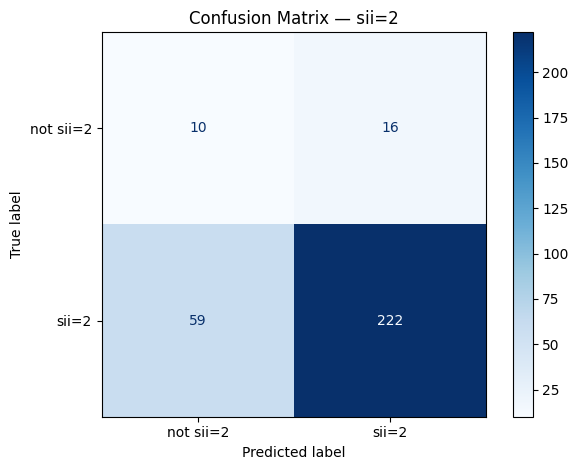

              precision    recall  f1-score   support

           0       0.14      0.38      0.21        26
           1       0.93      0.79      0.86       281

    accuracy                           0.76       307
   macro avg       0.54      0.59      0.53       307
weighted avg       0.87      0.76      0.80       307


  Confusion Matrix breakdown:
    TN (correct negatives) : 10
    FP (false positives)   : 16
    FN (false negatives)   : 59
    TP (correct positives) : 222


In [145]:
models[2] = train_one_step(X_tr, y_binary_tr, X_te, y_binary_te,
                            step_name='sii=2')

In [149]:
# ── DEBUG — find unassigned samples ──────────────────────────────────────
unassigned_idx = np.where(y_pred_final == -1)[0]
print(f"  Unassigned samples : {len(unassigned_idx)}")
print(f"  Their true labels  : {np.unique(y_test[unassigned_idx], return_counts=True)}")

  Unassigned samples : 634
  Their true labels  : (array([0., 1.]), array([521, 113], dtype=int64))


In [151]:
# Check overlap
print(f"  True sii=0 count         : {(y_test == 0).sum()}")
print(f"  Predicted as sii=0 count : {mask_0.sum()}")

  True sii=0 count         : 1738
  Predicted as sii=0 count : 1590


In [152]:
print(f"  True sii=1 in idx_1      : {(y_test[idx_1] == 1).sum()}")
print(f"  Predicted as sii=1 count : {mask_1.sum()}")

  True sii=1 in idx_1      : 470
  Predicted as sii=1 count : 475


  Samples assigned to sii=0 : 1590
  Samples assigned to sii=1 : 475
  Samples assigned to sii=2 : 238
  Samples assigned to sii=3 : 69


ValueError: The number of FixedLocator locations (5), usually from a call to set_ticks, does not match the number of labels (4).

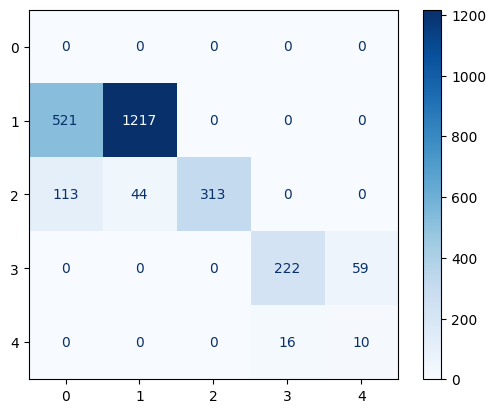

In [150]:
# ── FINAL PREDICTIONS — 3 model cascade ──────────────────────────────────

n_samples     = len(X_test)
y_pred_final  = np.full(n_samples, -1)  # -1 = unassigned placeholder

# ── Model 0: sii=0 vs [1,2,3] ────────────────────────────────────────────
preds_0 = models[0].predict(X_test)
mask_0  = preds_0 == 1                          # predicted as sii=0
y_pred_final[mask_0] = 0
print(f"  Samples assigned to sii=0 : {mask_0.sum()}")

# ── Model 1: sii=1 vs [2,3] — only on true non-0 samples ─────────────────
idx_1   = np.where(y_test != 0)[0]             # true label is not 0
preds_1 = models[1].predict(X_test[idx_1])
mask_1  = preds_1 == 1                          # predicted as sii=1
y_pred_final[idx_1[mask_1]] = 1
print(f"  Samples assigned to sii=1 : {mask_1.sum()}")

# ── Model 2: sii=2 vs 3 — only on true non-0, non-1 samples ──────────────
idx_2   = np.where((y_test != 0) & (y_test != 1))[0]   # true label is 2 or 3
preds_2 = models[2].predict(X_test[idx_2])
mask_2  = preds_2 == 1                          # predicted as sii=2
y_pred_final[idx_2[mask_2]]  = 2               # predicted sii=2
y_pred_final[idx_2[~mask_2]] = 3               # rest → sii=3
print(f"  Samples assigned to sii=2 : {mask_2.sum()}")
print(f"  Samples assigned to sii=3 : {(~mask_2).sum()}")

# # ── Sanity check — no unassigned samples ─────────────────────────────────
# assert -1 not in y_pred_final, "Some samples were not assigned a class!"
# print(f"\n  Total assigned : {len(y_pred_final)} / {n_samples} ✓")

# ── Overall confusion matrix ──────────────────────────────────────────────
cm_final = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final,
                               display_labels=[f'sii={c}' for c in classes])
disp.plot(cmap='Blues')
plt.title('Final Confusion Matrix — Full Cascade (sii)')
plt.tight_layout()
plt.show()

# ── Classification report ─────────────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final,
                             target_names=[f'sii={c}' for c in classes]))

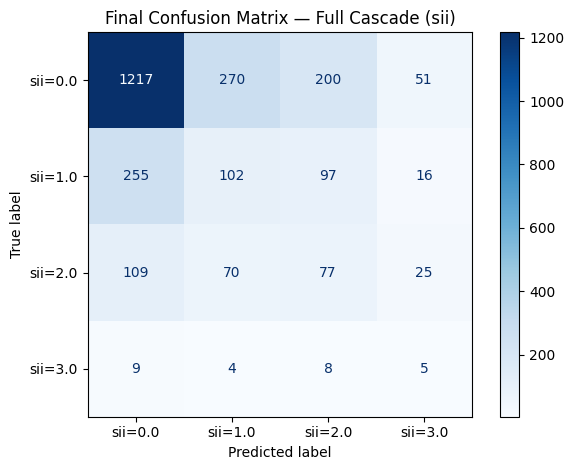


Classification Report:
              precision    recall  f1-score   support

     sii=0.0       0.77      0.70      0.73      1738
     sii=1.0       0.23      0.22      0.22       470
     sii=2.0       0.20      0.27      0.23       281
     sii=3.0       0.05      0.19      0.08        26

    accuracy                           0.56      2515
   macro avg       0.31      0.35      0.32      2515
weighted avg       0.59      0.56      0.57      2515



In [147]:
# Rebuild full predictions on original test set
n_samples    = len(X_test)
y_pred_final = np.full(n_samples, classes[-1])
remaining_idx = np.arange(n_samples)

for cls in classes[:-1]:
    if len(remaining_idx) == 0:
        break
    preds = models[cls].predict(X_test[remaining_idx])
    positive_mask = preds == 1
    y_pred_final[remaining_idx[positive_mask]] = cls
    remaining_idx = remaining_idx[~positive_mask]

# Overall confusion matrix
cm_final = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final,
                               display_labels=[f'sii={c}' for c in classes])
disp.plot(cmap='Blues')
plt.title('Final Confusion Matrix — Full Cascade (sii)')
plt.tight_layout()
plt.show()

# Full report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final,
                             target_names=[f'sii={c}' for c in classes]))

In [23]:
over_dic={1:2500,2:2000,3:1500}
under_dic={0:3000}

In [24]:
over = SMOTE(random_state=42, sampling_strategy=over_dic)
under = TomekLinks(sampling_strategy='majority')

## Logistic Regression RandomSearch

In [25]:
# ── Usage inside pipeline ─────────────────────────────────────────────────────
from imblearn.pipeline import Pipeline

pipeline = Pipeline([
    #('over',  over),
    #('under', under),
    ('clf',   CascadeDecisionTreeClassifier(
                  n_iter=200,
                  n_splits=10,
                  random_state=0)
    )
])

pipeline.fit(X_train, y_train)
y_pred  = pipeline.predict(X_test)
y_score = pipeline.predict_proba(X_test)   # shape (n_samples, n_classes)

# ── Access all info ───────────────────────────────────────────────────────────
info = pipeline['clf'].info_

print(info['best_params'])    # best params per cascade step
print(info['best_scores'])    # best F1 per cascade step

CASCADE DECISION TREE — TRAINING
  Classes   : [0. 1. 2. 3.]
  n_classes : 4
  n_samples : 5867

── Step 1: class 0.0 vs [1.0, 2.0, 3.0] ──
  [class 0.0 vs [1.0, 2.0, 3.0]] best params  : {'min_samples_split': 0.05, 'min_samples_leaf': 50, 'max_depth': 17, 'criterion': 'gini', 'class_weight': None}
  [class 0.0 vs [1.0, 2.0, 3.0]] best F1 score: 0.6528
  [class 0.0 vs [1.0, 2.0, 3.0]] samples used : 5867

  Remaining samples for next step: 914

── Step 2: class 1.0 vs [2.0, 3.0] ──
  [class 1.0 vs [2.0, 3.0]] best params  : {'min_samples_split': 0.03, 'min_samples_leaf': 20, 'max_depth': 16, 'criterion': 'gini', 'class_weight': None}
  [class 1.0 vs [2.0, 3.0]] best F1 score: 0.5932
  [class 1.0 vs [2.0, 3.0]] samples used : 914

  Remaining samples for next step: 680

── Step 3: class 2.0 vs [3.0] ──
  [class 2.0 vs [3.0]] best params  : {'min_samples_split': 0.05, 'min_samples_leaf': 30, 'max_depth': 4, 'criterion': 'gini', 'class_weight': None}
  [class 2.0 vs [3.0]] best F1 score: 

In [ ]:
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5001988071570577
F1-score [0.70453095 0.19327731 0.22900763 0.03795066]
              precision    recall  f1-score   support

         0.0       0.79      0.64      0.70      1738
         1.0       0.28      0.15      0.19       470
         2.0       0.20      0.27      0.23       281
         3.0       0.02      0.38      0.04        26

    accuracy                           0.50      2515
   macro avg       0.32      0.36      0.29      2515
weighted avg       0.62      0.50      0.55      2515



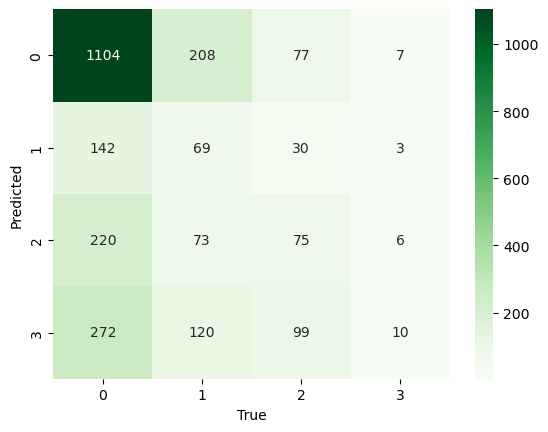

In [ ]:
cf = confusion_matrix(y_pred,y_test)
sns.heatmap(cf, annot=True, cmap="Greens",fmt='g')
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

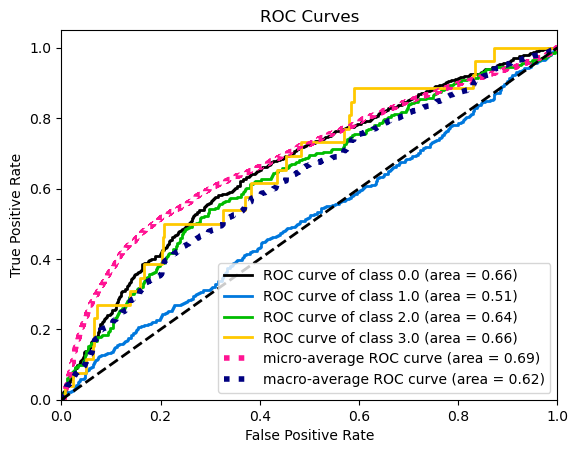

In [ ]:
# roc
plot_roc(y_test, y_score)
plt.show()